# Practical Work 4: Introduction to Gradient Descent with Pytorch

<br/><br/>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
print(torch.__version__)

2.8.0+cu126


We will find the minimum of the function $f : \mathbb{R}^2 \to \mathbb{R}$ defined by
$$ f(x) = f(x_0,x_1) = x_0^2 + x_1^2 - \sin(2x_0)x_1 \quad .$$

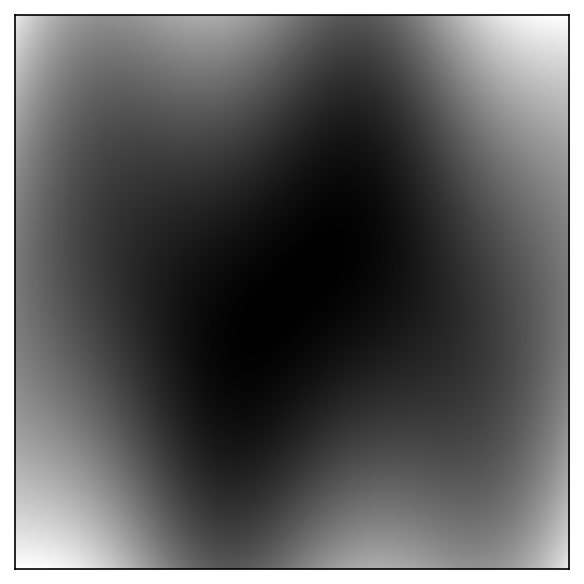

In [2]:
nr,nc = 256,256
a = 3
extent = ((-a-0.5/nc, a-0.5/nc, -a-0.5/nr, a-0.5/nr))
xs = np.linspace(a, -a, nr)
ys = np.linspace(-a, a, nc)
xm, ym = np.meshgrid(xs, ys, indexing='ij')
xm = xm.T
ym = ym.T

y = xm**2 + ym**2 - np.sin(2*xm)*ym

# other choices (just for fun):
#   y = np.sqrt(1+xm**2 + ym**2 - np.sin(xm*2)*ym)
#   y = 2*ym**2-np.cos(xm*3)*ym + 2*xm**2

fig = plt.figure(dpi=150)
plt.xticks([])
plt.yticks([])
plt.imshow(y,cmap = 'gray', extent=extent)
plt.show()

**QUESTION :**

- Define the function $f$ in Pytorch: `f`should take a torch.tensor `x` of shape $(2)$ as input and should output $f(x)$.
- Test the function $f$ by computing $f(x)$ for $x=(0,1)$.
- Compute its gradient at point $x=(0,1)$ with Pytorch.
- Can you check the obtained values?

In [8]:
def f(x):
    x1, x2 = x[0], x[1]
    return x1**2 + x2**2 - torch.sin(2*x1) * x2


# Test the function at x = (0, 1)
x = torch.tensor([0.0, 1.0], requires_grad=True)
y = f(x)
print("f(x) =", y.item())

# Compute gradient
y.backward()
print("∇f(x) =", x.grad)

f(x) = 1.0
∇f(x) = tensor([-2.,  2.])


**QUESTION :** Look at the following cell, which implements gradient descent (with fixed step size $\tau$).

Try to understand each line of this code.

/tmp/ipython-input-1233662703.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xd[n,:] = x.detach().cpu()


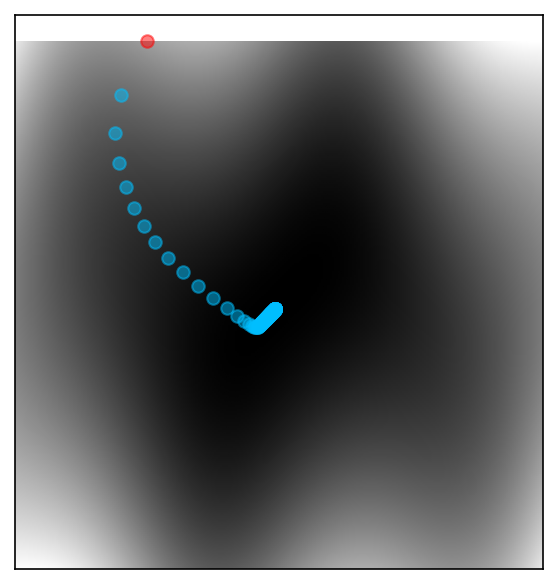

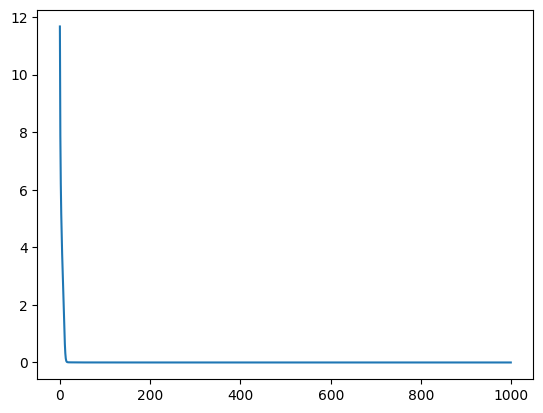

In [9]:

y = xm**2 + ym**2 - np.sin(xm*2)*ym   # copy the formula to display function values in background

x0 = np.array([-1.5,3.])
x = torch.tensor(x0, requires_grad=True)

tau = 0.1
N = 1000
xd = np.zeros((N,2))

fxlist = []

for n in range(N):
    fx = f(x)
    fx.backward()
    with torch.no_grad():
        x -= tau*x.grad
    x.grad.zero_()
    xd[n,:] = x.detach().cpu()
    fxlist.append(fx.item())

fig = plt.figure(dpi=150)
plt.xticks([])
plt.yticks([])
plt.imshow(y,cmap = 'gray', extent=extent)
plt.scatter(x0[0], x0[1],c='red',alpha=.5)
plt.scatter(xd[:, 0], xd[:,1],c='deepskyblue',alpha=.5)
plt.show()

plt.figure(dpi=100)
plt.plot(fxlist)
plt.show()

**QUESTION:** Compare by doing gradient descent with the Pytorch routine ``torch.optim.SGD`` as follows.

In [12]:
x = torch.tensor(x0, requires_grad=True)
optim = torch.optim.SGD([x], lr=tau)
losslist = []
for it in range(N):
    loss = f(x)
    losslist.append(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()





